<a href="https://colab.research.google.com/github/drishtisinghsks-hub/AI-based-hiring-prediction-system/blob/main/Fake_Job_Posting_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
df = pd.read_csv('/content/fake_job_postings.csv', on_bad_lines='skip')

In [ ]:

print(df.head())


print(df.tail())


print(df.sample(n=5))


   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         description  \
0  Foo

In [ ]:
print(df.shape)

(31937, 18)


In [ ]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [ ]:
print("\nData Types:")
print(df.dtypes)



Data Types:
job_id                   int64
title                   object
location                object
department              object
salary_range            object
company_profile         object
description             object
requirements            object
benefits                object
telecommuting           object
has_company_logo        object
has_questions           object
employment_type         object
required_experience     object
required_education      object
industry                object
function                object
fraudulent             float64
dtype: object


In [ ]:
print("\nValue Counts (Recruiter Decision):")
print(df['fraudulent'].value_counts())


Value Counts (Recruiter Decision):
fraudulent
0.0    30310
1.0     1605
Name: count, dtype: int64


In [ ]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
             job_id    fraudulent
count  31937.000000  31915.000000
mean    9774.972728      0.050290
std     4804.712937      0.218546
min        1.000000      0.000000
25%     5890.000000      0.000000
50%     9887.000000      0.000000
75%    13885.000000      0.000000
max    17880.000000      1.000000


In [ ]:
df.fillna('', inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df = df[['title', 'description', 'requirements', 'company_profile', 'fraudulent']]

In [ ]:
df['text'] = (
    df['title'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['company_profile']
)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-z]', ' ', text)  # remove symbols/numbers
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
print(df['fraudulent'].value_counts())

fraudulent
0.0    16993
1.0      866
          22
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['fraudulent']

In [ ]:
print(df['fraudulent'].unique())
print(df['fraudulent'].dtype)

[0.0 1.0 '']
object


In [ ]:
df['fraudulent'] = pd.to_numeric(df['fraudulent'], errors='coerce')
df = df.dropna(subset=['fraudulent'])
df['fraudulent'] = df['fraudulent'].astype(int)

In [ ]:
X = vectorizer.fit_transform(df['clean_text'])
y = df['fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_nb = nb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
acc_lr = accuracy_score(y_test, y_pred_lr)
print("🔹 Logistic Regression")
print("Accuracy:", acc_lr)
print(classification_report(y_test, y_pred_lr))

# Naive Bayes
acc_nb = accuracy_score(y_test, y_pred_nb)
print("\n🔹 Naive Bayes")
print("Accuracy:", acc_nb)
print(classification_report(y_test, y_pred_nb))

🔹 Logistic Regression
Accuracy: 0.9717245240761478
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3399
           1       0.99      0.42      0.59       173

    accuracy                           0.97      3572
   macro avg       0.98      0.71      0.79      3572
weighted avg       0.97      0.97      0.97      3572


🔹 Naive Bayes
Accuracy: 0.9672452407614781
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3399
           1       0.95      0.34      0.50       173

    accuracy                           0.97      3572
   macro avg       0.96      0.67      0.74      3572
weighted avg       0.97      0.97      0.96      3572



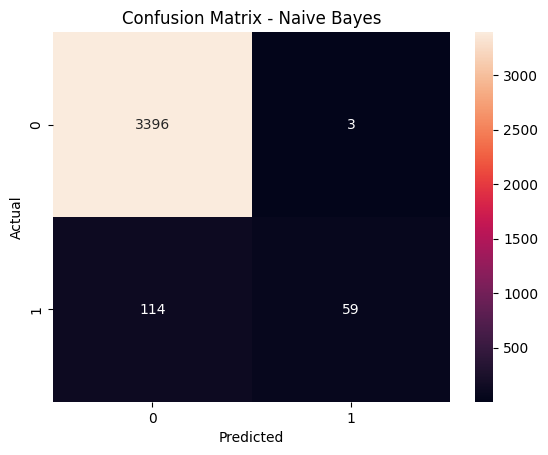

In [ ]:

cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [ ]:


comparison = pd.DataFrame({
    'Model Name': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [acc_lr, acc_nb]
})

print(comparison)

            Model Name  Accuracy
0  Logistic Regression  0.971725
1          Naive Bayes  0.967245


In [ ]:
def predict_job(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    result = nb.predict(vector)   # use best model

    return "Fake Job 🚨" if result[0] == 1 else "Real Job ✅"

# Test
print(predict_job("Earn money fast from home no experience"))

Real Job ✅
